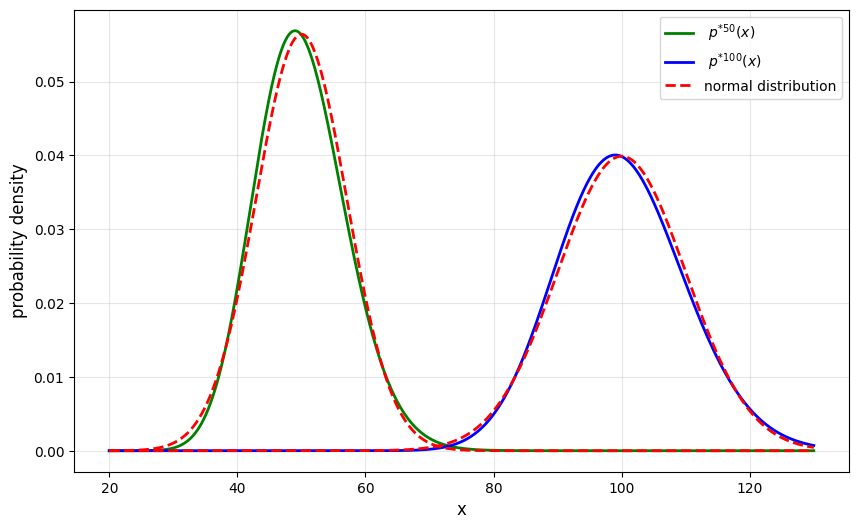

In [25]:
from math import factorial

# Task 4.1 d)
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import erlang, norm

# Parameter
N1 = 50
N2 = 100
w = 1.0  # Rate-Parameter (frei wählbar, hier 1.0)

# Berechnete Parameter für die Normalverteilung (Teil d)
mu1 = N1 / w
sigma1 = np.sqrt(N1) / w

mu2 = N2 / w
sigma2 = np.sqrt(N2) / w

# x-Bereich definieren (ca. 4 Standardabweichungen um den Mittelwert)
x = np.linspace(mu1 - 3*sigma, mu2 + 3*sigma, 1000)

# 1. Exakte N-fache Faltung (Erlang-Verteilung)
# In scipy ist 'a' der Shape-Parameter N und 'scale' ist 1/w
def pN(x, N, w):
    return (w*x)**N / (x * factorial(N-1)) * np.exp(-w*x)
p_exact1 = pN(x, N1, w)
p_exact2 = pN(x, N2, w)

# 2. Normalverteilung (Gauß-Fit)
p_fit1 = norm.pdf(x, loc=mu1, scale=sigma1)
p_fit2 = norm.pdf(x, loc=mu2, scale=sigma2)

# Visualisierung
plt.figure(figsize=(10, 6))
plt.plot(x, p_exact1, label=f' $p^{{*50}}(x)$', color='green', lw=2)
plt.plot(x, p_exact2, label=f' $p^{{*100}}(x)$', color='blue', lw=2)
plt.plot(x, p_fit1, label='normal distribution', color='red', linestyle='--', lw=2)
plt.plot(x, p_fit2, color='red', linestyle='--', lw=2)
plt.xlabel('x', fontsize=12)
plt.ylabel('probability density', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
#Task 2.3 Reconstruct probabilities from given moments
import sympy as sp

# 1. Define the matrix A
A = sp.Matrix([
    [1, 1, 1],
    [1, 3, 5],
    [1, 9, 25]
])

# 2. Define B as a matrix of symbols
b1, M1, M2 = sp.symbols('b1 M1 M2')
B = sp.Matrix([b1, M1, M2])

# 3. Solve the system Ax = B
x = A.solve(B)

numeric_x = x.subs({b1: 1})
print('solution for arbitrary moments M1, M2:')
sp.pprint(numeric_x)

numeric_x1 = x.subs({b1: 1, M1: 7/2, M2: 15})
print('solution for M1=7/2 and M2=15:')
sp.pprint(numeric_x1)


In [ ]:
# Task 2.3 reconstruct something
import numpy as np
import sympy as sp


# task b)
print("Task b)")
# Variablen definieren
M1, M2 = sp.symbols('M1 M2')

A = sp.Matrix([
    [1, 1, 1],
    [1, 3, 5],
    [1, 9, 25]
])

b = sp.Matrix([1, M1, M2])

x = A.LUsolve(b)  # oder A.solve(b)

print("Formula for Probabilities: ")
print(x)
print()

# task c)
print("Task c)")
x_expr = A.LUsolve(b)

# Examples, which lead to Unsinn
x_num = x_expr.subs({M1: 10, M2: 25})

print("Shit Probabilities")
print(x_num)
print()

# task d)
x_expr = A.LUsolve(b)

# Examples, which lead to good values
x_num = x_expr.subs({M1: 7/2, M2: 15})

Xvalues = [1, 3, 5]
print("Task d)")
print("Probabilities: ")
print(x_num)

def M(n, Probabilities, Xvalues):
    M = 0
    for P, X in zip(Probabilities, Xvalues):
        M += P * (X**n)
    return M

for n in range(0, 11):
    print("Moment " + str(n))
    Mn = M(n, x_num, Xvalues)
    print(Mn)